# Principal Component Analysis
This time, we'll statistically learn the patterns of a surface without neural networks. This statistical machinery is called **Principal Component Analysis**

We make our data by incorporating our tracker in Week 6.

## Data Conditioning

We first test the videos which frames should be obtained

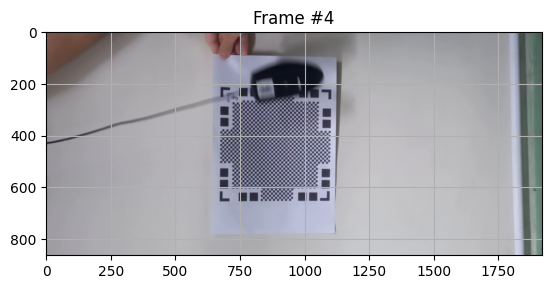

In [38]:
import matplotlib.pyplot as plt
import numpy as np
from imageio.v3 import *
import skimage
from skimage import morphology
from scipy import ndimage


frames = [] # where we'll store frames of interest
"""
for id, frame in enumerate(imiter("Castor1.mp4")):
    frames.append(frame)
print(frames)
"""
for id, frame in enumerate(imiter("Data/Video4.mp4")):
    # Notice how this loop is essentially where you'll be doing
    # your per-frame image processing. Remember this pattern.
    if id == 4:
        break

fig, ax = plt.subplots()
# Difference between imshow and matshow? imshow appears to have
# a bit of blur while matshow displays the pixel values as-is. Why?
ax.imshow(frame)
ax.set_title(f"Frame #{id}")
ax.grid(True)

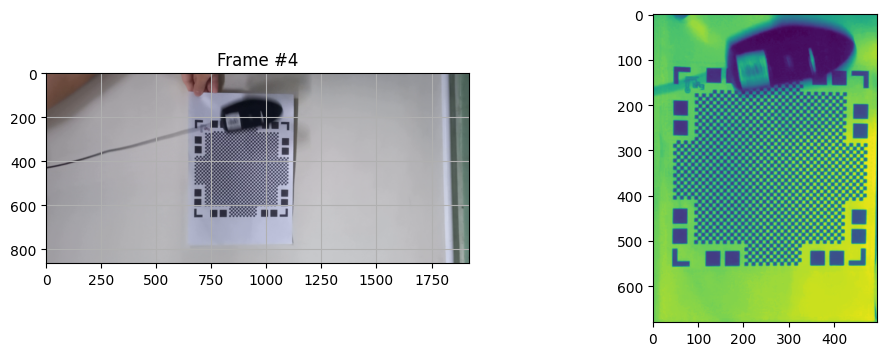

In [39]:
fig, (lax, rax) = plt.subplots(1, 2, figsize=(12, 4))
lax.imshow(frame)
lax.set_title(f"Frame #{id}")
lax.grid(True)

###       top-down   left-right  color chan.
crop = frame[100:780, 630:1125, 2] # In blue channel,
## this is where the ball is most prominent
rax.imshow(crop)

Text(0.5, 0, 'y')

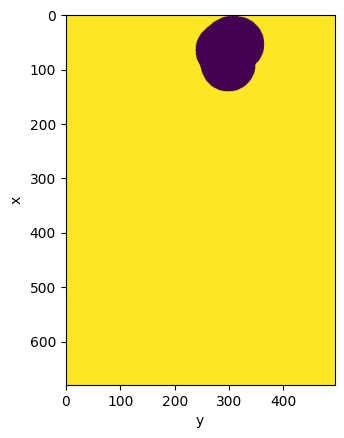

In [40]:
binarized = crop > 120 # Find the darkest spot
# binarized_fin = binarized > 85
# intensity 100+

footprint = morphology.disk(radius=50)
test1 = morphology.closing(binarized, footprint) # We choose test1

# footprint2 = morphology.disk(radius=20)
# test2 = morphology.closing(binarized, footprint2)


# fig, axs = plt.subplots(1, 3, figsize=(12, 4))

# axs[0].imshow(binarized)
plt.imshow(test1)
plt.ylabel("x")
plt.xlabel("y")
# axs[2].imshow(test2)

As we'll see below, we have to invert the threshold from "high-pass to "low-pass". Now, let's re-use the trajectory plot from Week 6.

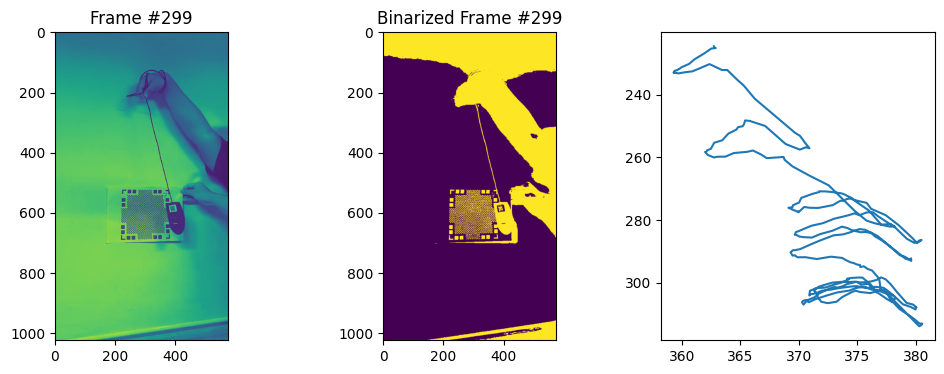

In [41]:
# Define the trajectory function
def trajectory(start, end, file):
    x_coords = []
    y_coords = []
    for id, timeframe in enumerate(imiter(file)):
        if id < start: # Since range is an exclusive end
            continue # Makes sure that the frame continues
        
        if id > end:
            break

        # change color channel when appropriate
        # binarize
        binarized = timeframe[:, :, 2] < 120 # threshold brightness
        y, x = ndimage.center_of_mass(binarized)
        y_coords.append(y)
        x_coords.append(x)

    return y_coords, x_coords, timeframe

y, x, timeframe = trajectory(0, 299, "Data/Video1.mp4")

# Clean NaNs (or just convert to arrays if you’re sure there are none)
x_fin = np.array(x)
y_fin = np.array(y)

# Example frame for plotting
frame = timeframe[:, :, 1]   # keep crop consistent with trajectory
binarized = frame < 120

# Plot
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(frame)
axs[0].set_title("Frame #299")
axs[1].imshow(binarized)
axs[1].set_title("Binarized Frame #299")
axs[2].plot(x_fin, y_fin, label='coin trajectory')
axs[2].invert_yaxis()
plt.savefig("Final_plot.pdf")



Now, let's make the data matrix from superposition of four videos 

In [42]:
# Let's make the data matrix
def data_matrix(videos):
    matrices = []
    for file in videos:
        yi, xi, timeframe = trajectory(0, 294, file) # Since the last video has only 295 frames
        y_fin = np.array(yi)
        x_fin = np.array(xi)
        y.append(y_fin)
        x.append(x_fin)
        data = np.vstack([x_fin, y_fin])
        matrices.append(data) # Videos are stacked vertically
        stacked = np.array(matrices)
    return stacked

In [43]:
video_rack = ["Data/Video1.mp4", "Data/Video2.mp4", "Data/Video3.mp4", "Data/Video4.mp4"]
print(data_matrix(video_rack).shape)

(4, 2, 295)


## Pendulum Classification
Now, with the trajectories loaded up, we're now ready to process this

In [48]:
# For the first part, we're going to set up the principal components
data_input = data_matrix(video_rack)

# Mean-center
feat_mean = data_input.mean(axis=0, keepdims=True)# We mean based on samples


# The transposes are needed to properly broacast the
# mean-substraction across each column/feature.
data_final = data_input - feat_mean

# Faltten to 2D
n_samples, n_features, n_time = data_input.shape
data_2d = data_final.reshape(n_samples*n_features, n_time)

sample_dim = np.size(data_2d, axis=0)
# If you want to reconstruct exactly the original data and
# not the mean-shifted one, don't forget to add back the means.
cov_mat = (data_2d @ data_2d.T)/(sample_dim - 1)

# Instead of doing SVD, we can go straight into taking
# the eigenvalues/eigenvectors of the matrix:
evals, evec = np.linalg.eigh(cov_mat)
# Q: is cov_mat guaranteed Hermitian? What are the implications?
# Q: given N-samples of M-features, what should be the shape of eigh outputs?
# Q: what is the ordering of the eigenvalues?

print(f"eval: {evals} \nevec: {evec}")

eval: [-4.10686797e-09 -8.61587898e-10  7.59539742e+02  2.02217086e+03
  9.38257572e+03  4.46820699e+04  1.08672023e+05  2.32204172e+07] 
evec: [[ 0.49402301 -0.07707962  0.56716761  0.20862661  0.23614865 -0.11070258
  -0.137942    0.54566162]
 [-0.07707962 -0.49402301 -0.31745243 -0.42667266  0.3645076  -0.36497241
  -0.42083843  0.15491532]
 [ 0.49402301 -0.07707962  0.03405715  0.05738036 -0.19887027  0.17734997
  -0.61167902 -0.5480821 ]
 [-0.07707962 -0.49402301  0.2878089   0.3285448   0.31909473 -0.2496427
   0.34279399 -0.52685264]
 [ 0.49402301 -0.07707962 -0.69473989  0.40320481  0.14608767  0.0267575
   0.26213701  0.11827501]
 [-0.07707962 -0.49402301 -0.01435901  0.20391568 -0.77847977 -0.22299862
   0.00156468  0.22902103]
 [ 0.49402301 -0.07707962  0.09351514 -0.66921178 -0.18336605 -0.09340489
   0.48748401 -0.11585453]
 [-0.07707962 -0.49402301  0.04400254 -0.10578782  0.09487744  0.83761373
   0.07647976  0.14291629]]


After obtaining eigenvalues and eigenvectors, we now work for reconstruction.

In [49]:
# We can get the "weights/coefficients" needed to reconstruct
# the original dataset given the new basis set. 
recons_wts = data_2d.T @ evec

# Compare original data and one recovered using the 
# reconstruction weights for each point
data_2d[:, 3], evec @ recons_wts[3]

(array([-413.71057122, -155.0435704 ,  348.77046146,  411.87645412,
         -74.89972342, -155.71215703,  139.83983318, -101.12072669]),
 array([-413.71057122, -155.0435704 ,  348.77046146,  411.87645412,
         -74.89972342, -155.71215703,  139.83983318, -101.12072669]))

We're aiming to reconstruct it on a feature, so we're sampling across features. Given we're dealing with trajectories.

In [50]:
orig = data_2d[:, 10]  # trajectory of a 

expl = np.cumsum(evals[::-1])
expl = expl / expl.max()

for i in range(1, sample_dim + 1):
    # Reconstruct trajectory
    dimred = evec[:, -i:] @ recons_wts[10, -i:]       # shape (time,)
    
    # Compare with original
    l2 = np.sqrt(np.sum((orig - dimred)**2))
    print(f"{i}, {expl[i-1]*100:.2f}% => {dimred} @ L2={l2:.4f}")

print(f"Orig is {orig}")


1, 99.29% => [-398.72341779 -113.19903276  400.49209979  384.9794063   -86.42538697
 -167.34922053   84.65670498 -104.43115301] @ L2=93.4763
2, 99.76% => [-410.98415209 -150.60452247  346.12407709  415.44805185  -63.12579604
 -167.21014644  127.98587104  -97.63338295] @ L2=28.9411
3, 99.95% => [-409.23971376 -144.85332991  343.32941706  419.38189223  -63.54743764
 -163.6961603   129.45773434 -110.83240202] @ L2=24.2750
4, 99.99% => [-414.85644397 -153.52304216  348.05949129  411.79231232  -67.02209251
 -145.18023451  133.81904519 -113.08903565] @ L2=4.8540
5, 100.00% => [-415.67908329 -151.84062152  347.83323377  410.49682141  -68.61197665
 -145.9842981   136.45782617 -112.67190179] @ L2=2.8308
6, 100.00% => [-417.2846058  -150.94198588  347.73682573  409.68209987  -66.64532602
 -145.94365101  136.19310608 -112.79646297] @ L2=0.0000
7, 100.00% => [-417.2846058  -150.94198588  347.73682573  409.68209987  -66.64532602
 -145.94365101  136.19310608 -112.79646297] @ L2=0.0000
8, 100.00% => 

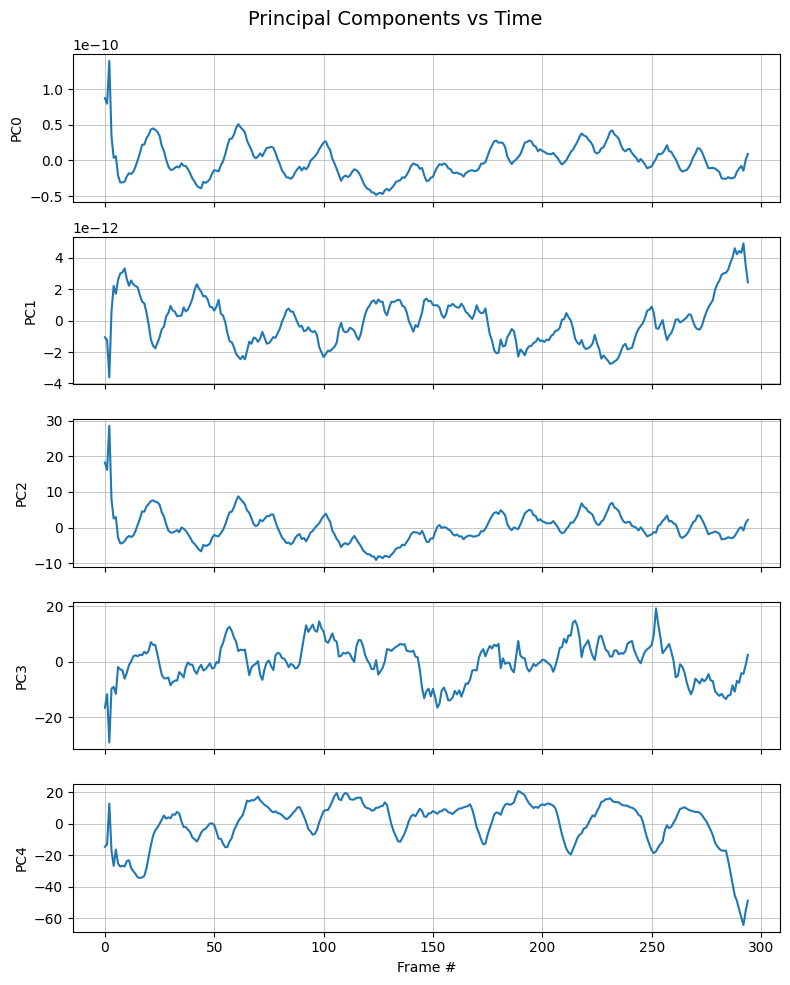

In [51]:
# # Let's make a function out of this
data_recons = recons_wts @ evec.T

# Suppose recon_wts has shape (n_frames, n_components)
n_frames = recons_wts.shape[0]

# Build a time axis: either simple frame indices or scaled by dt
time_axis = np.arange(n_frames)          # frames 0,1,2,...
# or, if you know the timestep dt:
# time_axis = np.arange(n_frames) * dt

fig, axes = plt.subplots(5, 1, figsize=(8, 10), sharex=True)

for i in range(5):  # PC0 to PC4
    axes[i].plot(time_axis, recons_wts[:, i], lw=1.5)
    axes[i].set_ylabel(f"PC{i}")
    axes[i].grid(True, lw=0.5)

axes[4].set_xlabel("Frame #")
fig.suptitle("Principal Components vs Time", fontsize=14)
plt.tight_layout()
plt.savefig("Pendulum.pdf")
plt.show()

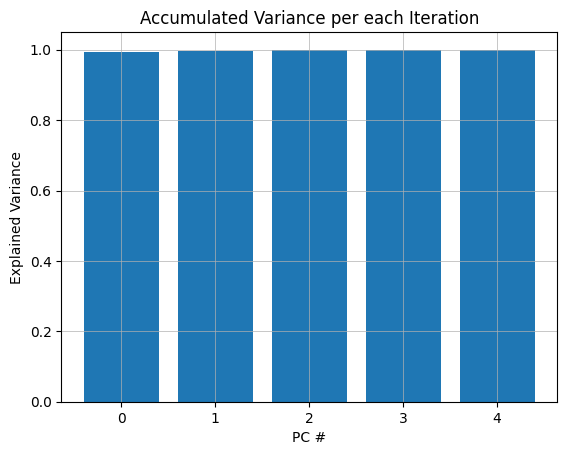

In [52]:
# Now, for the explained variance
plt.bar(range(5), expl[:5])
# plt.set(xlabel="PC #", ylabel="Explained Variance")
plt.xlabel("PC #")
plt.ylabel("Explained Variance")
plt.title("Accumulated Variance per each Iteration")
plt.grid(True, lw=0.5)
plt.savefig("Pendulum_PC.pdf")
plt.show()

In [25]:
print(n_time)

295


## Face Data

Now we're dealing with multiple photos of a face and reconstruct an average face from Principal Component Analyses

Dataset shape is: (400, 112, 92)


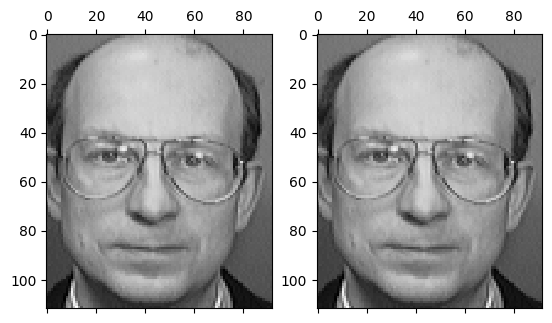

In [53]:
# Let's study the data
# Import the Face Data
# How to load the npz dataset?
dataset = np.load("Data/att-faces-400.npz")['dataset']
print(f"Dataset shape is: {dataset.shape}")
# Note: you should get 400 samples of 112 x 92 images

# Consider pic#123
facepic = dataset[123, :, :]

fig, (ax, ax2) = plt.subplots(1, 2)

# #123 should look like this...
ax.matshow(facepic, cmap="gray")

# Ravel will turn a 2D array into 1D vector
facevec = np.ravel(facepic)

# To turn it back into 2D, reshape the vector
# into the original 112 x 92 array. 
show_face = facevec.reshape(112, 92)
ax2.matshow(show_face, cmap="gray")

As in the Pendulum Case, we construct a vector of 400 face images.

In [54]:
# print(dataset.shape) # This should yield [400 images, 112 rows, 92 columns

# After knowing the image is of the right shape you already decompose it to a 2D matrix, so we can extract the feature means
# Mean-center
feat_mean = dataset.mean(axis=0, keepdims=True)# We mean based on samples


# The transposes are needed to properly broacast the
# mean-substraction across each column/feature.
mean_cntrd = dataset - feat_mean

# Faltten to 2D
n_image, n_x, n_y = mean_cntrd.shape
data_2d = mean_cntrd.reshape(n_image, n_x*n_y)

sample_dim = np.size(data_2d, axis=0)
# If you want to reconstruct exactly the original data and
# not the mean-shifted one, don't forget to add back the means.
cov_mat = (data_2d @ data_2d.T)/(sample_dim - 1)

# Instead of doing SVD, we can go straight into taking
# the eigenvalues/eigenvectors of the matrix:
evals, evec = np.linalg.eigh(cov_mat)
# Q: is cov_mat guaranteed Hermitian? What are the implications?
# Q: given N-samples of M-features, what should be the shape of eigh outputs?
# Q: what is the ordering of the eigenvalues?

print(f"eval: {evals} \nevec: {evec}")

eval: [-3.08184232e-10  1.05516950e+03  1.08637248e+03  1.19901543e+03
  1.23454793e+03  1.31142029e+03  1.34243112e+03  1.39348461e+03
  1.47217142e+03  1.51197693e+03  1.52881793e+03  1.57070269e+03
  1.62385436e+03  1.63105474e+03  1.68527650e+03  1.69736948e+03
  1.73073071e+03  1.74610410e+03  1.78407173e+03  1.83511463e+03
  1.84284293e+03  1.86886908e+03  1.88455652e+03  1.90675841e+03
  1.92774089e+03  1.95239157e+03  1.98232064e+03  1.98366895e+03
  2.00758158e+03  2.02300567e+03  2.03402577e+03  2.07222538e+03
  2.07716998e+03  2.11093451e+03  2.13690291e+03  2.15328384e+03
  2.19002421e+03  2.20634147e+03  2.23439689e+03  2.24291793e+03
  2.25120936e+03  2.29838447e+03  2.30749288e+03  2.33281674e+03
  2.35720095e+03  2.38120391e+03  2.39854800e+03  2.40547127e+03
  2.41359773e+03  2.43529150e+03  2.44933298e+03  2.46443129e+03
  2.51232491e+03  2.51557901e+03  2.53218455e+03  2.55116235e+03
  2.56638508e+03  2.58453289e+03  2.60650202e+03  2.61205959e+03
  2.63995191e+03  2

Now, let's test making the plots for this image. Consider Image #4 again and its different PCs

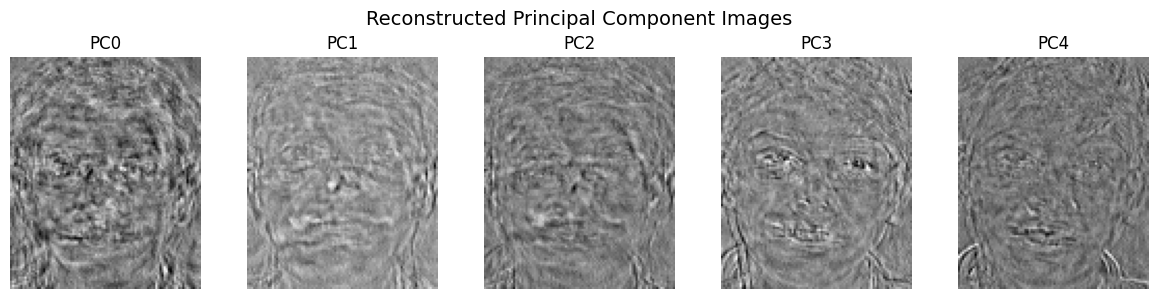

In [67]:
# Let's make a function out of this
recons_wts = data_2d.T @ evec

# Suppose recon_wts has shape (n_frames, n_components)
n_pc_show = 5
fig, axes = plt.subplots(1, n_pc_show, figsize=(12, 3))

for i in range(n_pc_show):
        # Take the i-th reconstructed sample (or PC image)
        pc_image = (evec[:, i] @ data_2d).reshape(n_x, n_y)
    
        axes[i].imshow(pc_image, cmap="gray")
        axes[i].set_title(f"PC{i}")
        axes[i].axis("off")

plt.suptitle("Reconstructed Principal Component Images", fontsize=14)
plt.tight_layout()
plt.show()

To make it easier to reconstruct an image, we define a reconstruction function, not just an equation, for easier iterability of superposed principal components whose range is integrally non-consecutive.

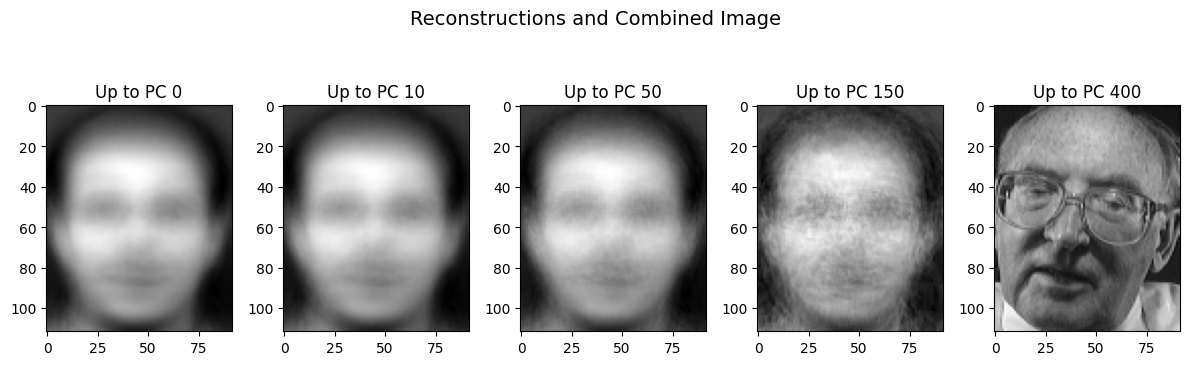

In [76]:
# Reconstruction function
def reconstruct_with_k(k):
    recons_wtsk = recons_wts[:, :k]   # (n_samples, k)
    evecs_k = evec[:, :k]             # (n_features, k)
    recons = (recons_wtsk @ evecs_k.T).T  # (n_samples, n_features)
    recons += feat_mean.reshape(1, -1)
    return recons

# Choose one sample image
sample_idx = 3 

# Get reconstructions with PC#50 and PC#100
n = [0, 10, 50, 150, 400]
recons1 = reconstruct_with_k(n[0])[sample_idx].reshape(n_x, n_y)
recons2 = reconstruct_with_k(n[1])[sample_idx].reshape(n_x, n_y)
recons3 = reconstruct_with_k(n[2])[sample_idx].reshape(n_x, n_y)
recons4 = reconstruct_with_k(n[3])[sample_idx].reshape(n_x, n_y)
recons5 = reconstruct_with_k(n[4])[sample_idx].reshape(n_x, n_y)
recons_tray = [recons1, recons2, recons3, recons4, recons5]


# Plot side by side
fig, axes = plt.subplots(1, len(n), figsize=(12, 4))

for i in range(len(n)):
    axes[i].imshow(recons_tray[i], cmap="gray")
    axes[i].set_title(f"Up to PC {n[i]}")

# axes[0].imshow(recons_50, cmap="gray")
# axes[0].set_title("Up to PC#50")
# axes[0].axis("off")

# axes[1].imshow(recons_100, cmap="gray")
# axes[1].set_title("Up to PC#100")
# axes[1].axis("off")

# axes[2].imshow(combined, cmap="gray")
# axes[2].set_title("PC#50 + PC#100")
# axes[2].axis("off")

plt.suptitle("Reconstructions and Combined Image", fontsize=14)
plt.tight_layout()
plt.savefig("Image Reconstruction.pdf")
plt.show()


Now, for the PC plots

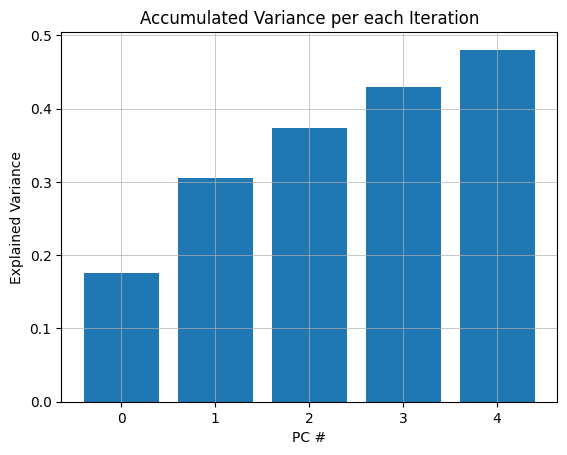

In [78]:
expl = np.cumsum(evals[::-1])
expl = expl / expl.max()
# Now, for the explained variance
plt.bar(range(5), expl[:5])
# plt.set(xlabel="PC #", ylabel="Explained Variance")
plt.xlabel("PC #")
plt.ylabel("Explained Variance")
plt.title("Accumulated Variance per each Iteration")
plt.grid(True, lw=0.5)
plt.savefig("Image_PC.pdf")
plt.show()

Due to the variety of features in a face, we see that the convergence is slower in an image, this has 400 eigenvectors by the way, since we have 400 images as our sample.